---
title: "3 - Modelos estadísticos con statsmodels"
toc: true
---

## ¿Qué es `statsmodels`?

[`statsmodels`](https://www.statsmodels.org/) es una de las librerías más completas de Python para análisis estadístico. Ofrece herramientas para estimación, inferencia y diagnóstico en una amplia variedad de métodos.

Es especialmente útil cuando queremos trabajar con regresión lineal clásica, modelos lineales generalizados, modelos discretos, series de tiempo y otras herramientas que resultan familiares desde la estadística aplicada.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyprojroot
import seaborn as sns

ROOT = pyprojroot.here()

Como muchas librerías grandes de Python, `statsmodels` está organizado en módulos. Distintos submódulos agrupan herramientas para tareas diferentes, por ejemplo modelos generales, fórmulas, tests y diagnósticos.


In [2]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Regresión lineal

Empezamos con una regresión lineal clásica usando `palmerpenguins`. Vamos a predecir `body_mass_g` a partir de otras variables numéricas del conjunto de datos.


In [3]:
datos_penguins = pl.read_csv(ROOT / "datos" / "palmerpenguins.csv")
datos_penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
i64,str,str,f64,f64,i64,i64,str,i64
1,"""Adelie""","""Torgersen""",39.1,18.7,181,3750,"""male""",2007
2,"""Adelie""","""Torgersen""",39.5,17.4,186,3800,"""female""",2007
3,"""Adelie""","""Torgersen""",40.3,18.0,195,3250,"""female""",2007
4,"""Adelie""","""Torgersen""",null,null,null,null,null,2007
5,"""Adelie""","""Torgersen""",36.7,19.3,193,3450,"""female""",2007
…,…,…,…,…,…,…,…,…
340,"""Chinstrap""","""Dream""",55.8,19.8,207,4000,"""male""",2009
341,"""Chinstrap""","""Dream""",43.5,18.1,202,3400,"""female""",2009
342,"""Chinstrap""","""Dream""",49.6,18.2,193,3775,"""male""",2009


En este apunte vamos a usar las siguientes columnas de `palmerpenguins`:

* `bill_length_mm`: longitud del pico en milímetros.
* `bill_depth_mm`: profundidad del pico en milímetros.
* `flipper_length_mm`: longitud de la aleta en milímetros.
* `body_mass_g`: masa corporal en gramos.
* `species`: especie del pingüino; la usamos cuando incorporamos predictores categóricos.


Antes de ajustar el modelo, conviene mirar la relación entre las variables numéricas que vamos a usar.


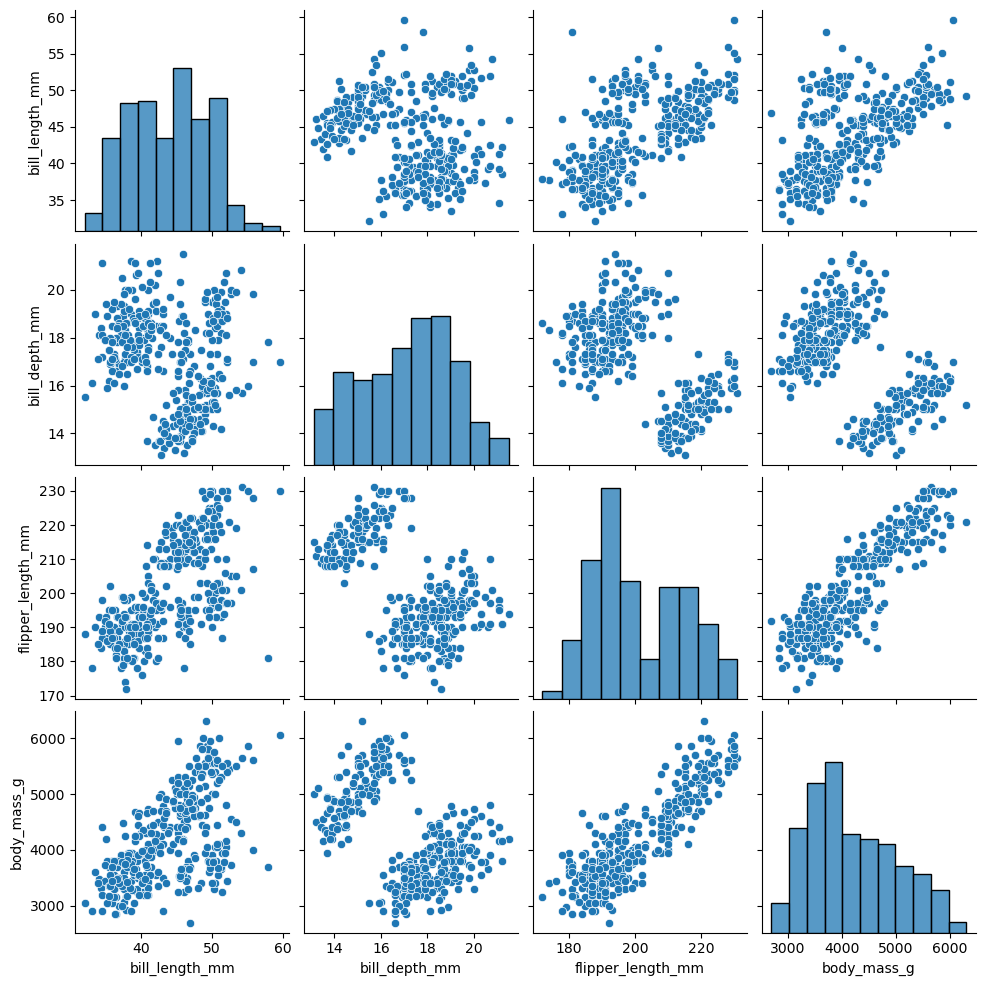

In [4]:
sns.pairplot(
    datos_penguins.drop_nulls(
        ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
    ).select(
        "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"
    ).to_pandas()
)

Para crear el modelo de regresión lineal, necesitamos construir la matriz de diseño `X` y el vector de respuestas `y`.


In [5]:
datos_penguins_num = datos_penguins.drop_nulls(
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
)

X = sm.add_constant(
    datos_penguins_num.select("bill_length_mm", "bill_depth_mm", "flipper_length_mm").to_numpy()
)
y = datos_penguins_num.select("body_mass_g").to_numpy().flatten()

In [6]:
print("shape de X:", X.shape)
X[:5]

shape de X: (342, 4)


array([[  1. ,  39.1,  18.7, 181. ],
       [  1. ,  39.5,  17.4, 186. ],
       [  1. ,  40.3,  18. , 195. ],
       [  1. ,  36.7,  19.3, 193. ],
       [  1. ,  39.3,  20.6, 190. ]])

In [7]:
print("shape de y:", y.shape)
y[:10]

shape de y: (342,)


array([3750, 3800, 3250, 3450, 3650, 3625, 4675, 3475, 4250, 3300])

Una vez que tenemos `X` e `y`, inicializamos un modelo con `OLS`.


In [8]:
modelo_ols = sm.OLS(y, X)
modelo_ols


Luego aplicamos `fit()` para obtener un objeto con los resultados del ajuste.



In [9]:
resultado_ols = modelo_ols.fit()
resultado_ols


El objeto ajustado concentra casi todo lo que solemos usar en un análisis de regresión.



In [10]:
resultado_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Tue, 19 May 2026   Prob (F-statistic):          8.19e-105
Time:                        16:59:48   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6424.7647    561.469    -11.443      0.000   -7529.179   -5320.351
x1             4.1618      5.329      0.781      0.435      -6.321      14.644
x2            20.0495     13.694      1.464      0.144      -6.887      46.986
x3            50.2692      2.477     20.293      0.000      45.397      55.142
==============================================================================
Omnibus:                        5.263   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.072   Jarque-Bera (JB):                5.129
Skew:                           0.298   Prob(JB):                       0.0770
Kurtosis:                       3.065   Cond. No.                     5.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Estimacion de los parámetros:

In [11]:
resultado_ols.params

array([-6.42476470e+03,  4.16182047e+00,  2.00495331e+01,  5.02692216e+01])

Residuos:

In [12]:
print("shape de los residuos:", resultado_ols.resid.shape)
resultado_ols.resid[:10]

shape de los residuos: (342,)


array([ 538.38213163,  361.43568832, -656.34648268, -366.88987878,
        -52.96734016,  432.25907554,  741.15226683, -307.0097058 ,
        543.81555782, -125.47435694])

Valores ajustados:

In [13]:
print("shape de los valores ajustados:", resultado_ols.fittedvalues.shape)
resultado_ols.fittedvalues[:10]

shape de los valores ajustados: (342,)


array([3211.61786837, 3438.56431168, 3906.34648268, 3816.88987878,
       3702.96734016, 3192.74092446, 3933.84773317, 3782.0097058 ,
       3706.18444218, 3425.47435694])

Y algunos diagnósticos:

In [14]:
resultado_ols.get_influence().summary_frame().head()

,dfb_const,dfb_x1,dfb_x2,dfb_x3,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
0,0.064965,0.005695,-0.005188,-0.070324,0.004209,1.374603,0.008831,0.129752,1.376420,0.129923
1,0.054881,-0.000214,-0.029491,-0.045757,0.001564,0.922112,0.007306,0.079107,0.921907,0.079090
2,0.006473,0.053290,-0.032919,-0.020714,0.003230,-1.672224,0.004599,-0.113670,-1.676699,-0.113974
3,0.041533,0.078561,-0.065442,-0.055103,0.002977,-0.938880,0.013330,-0.109129,-0.938715,-0.109110
4,0.007667,0.006332,-0.012947,-0.005832,0.000067,-0.135610,0.014287,-0.016326,-0.135413,-0.016303


También podemos mirar algunos diagnósticos de residuos.

In [15]:
print(resultado_ols.resid.shape)
resultado_ols.resid[:5]

(342,)


array([ 538.38213163,  361.43568832, -656.34648268, -366.88987878,
        -52.96734016])

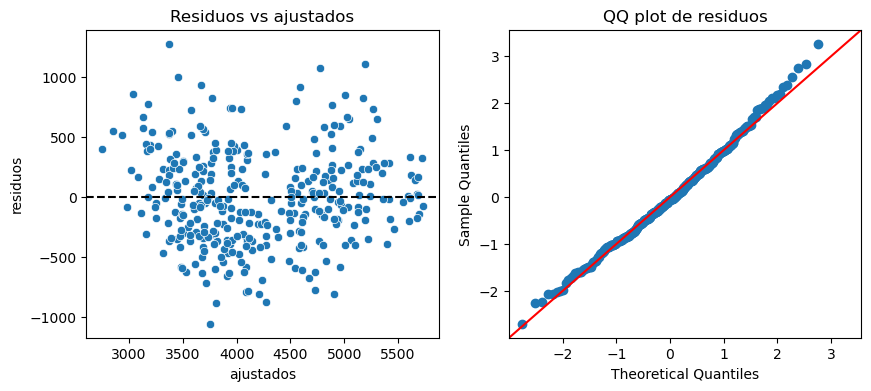

In [16]:
diagnostico_ols = pl.DataFrame(
    {"ajustados": resultado_ols.fittedvalues,  "residuos": resultado_ols.resid}
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(data=diagnostico_ols, x="ajustados", y="residuos", ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuos vs ajustados")

sm.qqplot(resultado_ols.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("QQ plot de residuos");


También podemos pedir predicciones con intervalos para la media condicional y para una nueva observación.



In [17]:
resultado_ols.get_prediction(X[:3]).summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,3211.617868,36.970000,3138.897607,3284.338130,2434.378345,3988.857392
1,3438.564312,33.626334,3372.421066,3504.707557,2661.912543,4215.216080
2,3906.346483,26.680291,3853.866156,3958.826810,3130.738834,4681.954132


## La interfaz de fórmulas

La API de fórmulas usa una sintaxis similar a la de R. Suele ser más cómoda cuando hay interacciones o variables categóricas.


In [18]:
datos_penguins_formula = datos_penguins.drop_nulls(
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "species"]
)

modelo_formula = smf.ols(
    "body_mass_g ~ flipper_length_mm",
    data=datos_penguins_formula.to_pandas(),
)

La construcción del modelo y el ajuste siguen separados, igual que con `sm.OLS`.


In [19]:
modelo_formula

In [20]:
resultado_formula = modelo_formula.fit()
resultado_formula

In [21]:
resultado_formula.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Tue, 19 May 2026   Prob (F-statistic):          4.37e-107
Time:                        16:59:49   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.190
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [22]:
resultado_formula.params

Intercept           -5780.831358
flipper_length_mm      49.685566
dtype: float64

Antes de incorporar interacciones, podemos mirar cómo cambian las nubes de puntos al distinguir observaciones por especie.


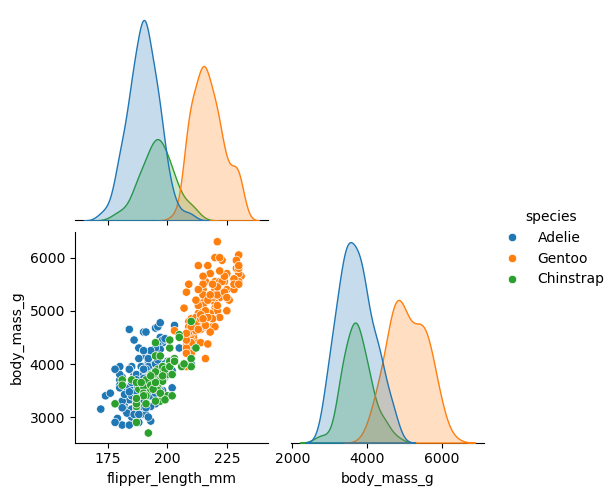

In [23]:
sns.pairplot(
    datos_penguins_formula.select("flipper_length_mm", "body_mass_g", "species").to_pandas(),
    hue="species",
    corner=True,
);

Ahora agregamos diferencias por especie en el intercepto y en la pendiente asociada a `flipper_length_mm`.


In [24]:
modelo_especie = smf.ols(
    "body_mass_g ~ flipper_length_mm * species",
    data=datos_penguins_formula.to_pandas(),
)

In [25]:
modelo_especie

In [26]:
resultado_especie = modelo_especie.fit()
resultado_especie

In [27]:
resultado_especie.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     252.2
Date:                Tue, 19 May 2026   Prob (F-statistic):          2.22e-111
Time:                        16:59:49   Log-Likelihood:                -2505.2
No. Observations:                 342   AIC:                             5022.
Df Residuals:                     336   BIC:                             5045.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                              -2535.8368    879.468     -2.883      0.004   -4265.793    -805.880
species[T.Chinstrap]                    -501.3590   1523.459     -0.329      0.742   -3498.078    2495.360
species[T.Gentoo]                      -4251.4438   1427.332     -2.979      0.003   -7059.077   -1443.811
flipper_length_mm                         32.8317      4.627      7.095      0.000      23.730      41.934
flipper_length_mm:species[T.Chinstrap]     1.7417      7.856      0.222      0.825     -13.711      17.194
flipper_length_mm:species[T.Gentoo]       21.7908      6.941      3.139      0.002       8.137      35.444
==============================================================================
Omnibus:                        5.822   Durbin-Watson:                   2.534
Prob(Omnibus):                  0.054   Jarque-Bera (JB):                5.758
Skew:                           0.317   Prob(JB):                       0.0562
Kurtosis:                       3.034   Cond. No.                     2.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Podemos comparar el `R^2` del modelo base con el del modelo que incorpora especie.


In [28]:
pl.DataFrame({
    "modelo": ["sin especie", "con especie"],
    "r2": [resultado_formula.rsquared, resultado_especie.rsquared],
    "r2_ajustado": [resultado_formula.rsquared_adj, resultado_especie.rsquared_adj],
})

modelo,r2,r2_ajustado
str,f64,f64
"""sin especie""",0.758993,0.758284
"""con especie""",0.789577,0.786446


In [29]:
resultado_especie.params

Intercept                                -2535.836802
species[T.Chinstrap]                      -501.358972
species[T.Gentoo]                        -4251.443811
flipper_length_mm                           32.831690
flipper_length_mm:species[T.Chinstrap]       1.741704
flipper_length_mm:species[T.Gentoo]         21.790812
dtype: float64

En el modelo con especie conviene revisar si los residuos siguen mostrando estructura por grupo.


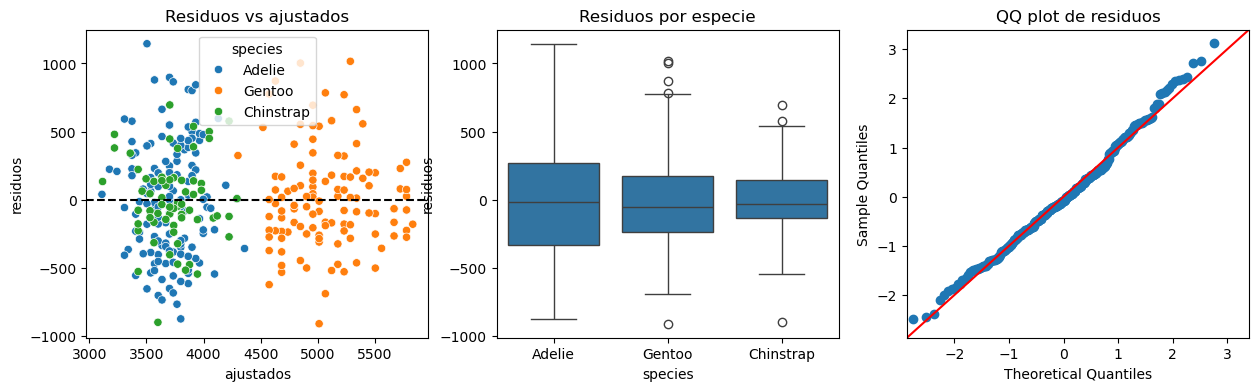

In [30]:
diagnostico_especie = pd.DataFrame(
    {
        "ajustados": resultado_especie.fittedvalues,
        "residuos": resultado_especie.resid,
        "species": datos_penguins_formula["species"].to_numpy(),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(
    data=diagnostico_especie,
    x="ajustados",
    y="residuos",
    hue="species",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuos vs ajustados")

sns.boxplot(data=diagnostico_especie, x="species", y="residuos", ax=axes[1])
axes[1].set_title("Residuos por especie")

sm.qqplot(resultado_especie.resid, line="45", fit=True, ax=axes[2])
axes[2].set_title("QQ plot de residuos");

Para predecir, pasamos un `DataFrame` con las covariables necesarias.


In [31]:
nuevos_pinguinos = pl.DataFrame(
    {
        "bill_length_mm": [39.5, 48.5, 46.0],
        "bill_depth_mm": [17.4, 15.0, 17.5],
        "flipper_length_mm": [186, 220, 210],
        "species": ["Adelie", "Gentoo", "Chinstrap"],
    }
)

predicciones_especie = pl.DataFrame(
    resultado_especie.get_prediction(nuevos_pinguinos.to_pandas()).summary_frame()
)
pl.concat([nuevos_pinguinos, predicciones_especie], how="horizontal")

bill_length_mm,bill_depth_mm,flipper_length_mm,species,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
f64,f64,i64,str,f64,f64,f64,f64,f64,f64
39.5,17.4,186,"""Adelie""",3570.857492,35.273766,3501.472251,3640.242732,2838.576597,4303.138386
48.5,15.0,220,"""Gentoo""",5229.669802,36.447733,5157.975311,5301.364293,4497.166493,5962.173111
46.0,17.5,210,"""Chinstrap""",4223.216937,100.594672,4025.34225,4421.091623,3467.852529,4978.581344


## Modelos lineales generalizados

Los modelos lineales generalizados extienden la regresión lineal a respuestas no gaussianas. En `statsmodels`, el patrón general sigue siendo el mismo: mostrar los datos, construir el modelo, ajustar y usar el objeto de resultados para inspección y predicción.


### Regresión logística

El dataset `spector` registra si un estudiante mejoró su nota (`GRADE`) junto con algunas covariables explicativas. Ajustamos un modelo logístico para obtener la probabilidad de mejora.


In [32]:
datos_spector = pl.from_pandas(sm.datasets.spector.load_pandas().data)
datos_spector

GPA,TUCE,PSI,GRADE
f64,f64,f64,f64
2.66,20.0,0.0,0.0
2.89,22.0,0.0,0.0
3.28,24.0,0.0,0.0
2.92,12.0,0.0,0.0
4.0,21.0,0.0,1.0
…,…,…,…
2.67,24.0,1.0,0.0
3.65,21.0,1.0,1.0
4.0,23.0,1.0,1.0


En este ejemplo usamos las siguientes columnas:

* `GRADE`: indica si la nota mejoró (`1`) o no (`0`).
* `GPA`: promedio del estudiante.
* `TUCE`: puntaje en un examen de economía.
* `PSI`: indicador de participación en el programa.


Primero construimos el modelo, dejando definida la fórmula y los datos, pero sin estimar todavía los parámetros.


In [33]:
modelo_logit = smf.logit("GRADE ~ GPA + TUCE + PSI", data=datos_spector.to_pandas())

In [34]:
modelo_logit

Después ajustamos el modelo. El resultado contiene coeficientes, errores estándar, medidas de ajuste y métodos para predicción.


In [35]:
resultado_logit = modelo_logit.fit(disp=False)
resultado_logit

In [36]:
resultado_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  GRADE   No. Observations:                   32
Model:                          Logit   Df Residuals:                       28
Method:                           MLE   Df Model:                            3
Date:                Tue, 19 May 2026   Pseudo R-squ.:                  0.3740
Time:                        16:59:50   Log-Likelihood:                -12.890
converged:                       True   LL-Null:                       -20.592
Covariance Type:            nonrobust   LLR p-value:                  0.001502
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -13.0213      4.931     -2.641      0.008     -22.687      -3.356
GPA            2.8261      1.263      2.238      0.025       0.351       5.301
TUCE           0.0952      0.142      0.672      0.501      -0.182       0.373
PSI            2.3787      1.065      2.234      0.025       0.292       4.465
==============================================================================
"""

In [37]:
resultado_logit.params

Intercept   -13.021347
GPA           2.826113
TUCE          0.095158
PSI           2.378688
dtype: float64

Si exponenciamos los coeficientes del modelo logístico, obtenemos los *odds ratios*.


In [38]:
np.exp(resultado_logit.params)

Intercept     0.000002
GPA          16.879715
TUCE          1.099832
PSI          10.790732
dtype: float64

La predicción por default devuelve probabilidades estimadas para `GRADE = 1`.


In [39]:
muestra_spector = datos_spector.head()
probabilidades = pl.DataFrame(
    {"probabilidad": resultado_logit.predict(muestra_spector.to_pandas())}
)
pl.concat([muestra_spector, probabilidades], how="horizontal")

GPA,TUCE,PSI,GRADE,probabilidad
f64,f64,f64,f64,f64
2.66,20.0,0.0,0.0,0.026578
2.89,22.0,0.0,0.0,0.059501
3.28,24.0,0.0,0.0,0.18726
2.92,12.0,0.0,0.0,0.025902
4.0,21.0,0.0,1.0,0.569893


### Regresión Poisson

El conjunto de datos `randhie` contiene un conteo de visitas médicas (`mdvis`). Es un ejemplo natural para un GLM Poisson.


In [40]:
datos_randhie = pl.from_pandas(sm.datasets.randhie.load_pandas().data)
datos_randhie

mdvis,lncoins,idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
i64,f64,i64,f64,f64,f64,f64,i64,i64,i64
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
2,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
…,…,…,…,…,…,…,…,…,…
2,0.0,0,5.377498,0.0,0.1442925,10.57626,0,0,0
0,0.0,0,5.377498,0.0,0.1442925,10.57626,0,0,0
8,3.258096,0,6.874819,8.006368,0.1442925,10.57626,0,0,0


En este modelo usamos:

* `mdvis`: número de visitas médicas.
* `lncoins`: logaritmo del coseguro.
* `idp`: indicador de plan con deducible individual.
* `lpi`: logaritmo de un incentivo de participación.
* `fmde`: medida vinculada al gasto médico esperado.
* `physlm`: indicador de limitación física.
* `disea`: número de enfermedades crónicas.
* `hlthg`, `hlthf`, `hlthp`: indicadores de estado de salud autopercibido.


Primero construimos el modelo. El objeto guarda la familia elegida, la función de enlace y la especificación del predictor lineal.


In [41]:
modelo_poisson = smf.glm(
    "mdvis ~ lncoins + idp + lpi + fmde + physlm + disea + hlthg + hlthf + hlthp",
    data=datos_randhie.to_pandas(),
    family=sm.families.Poisson(),
)

In [42]:
modelo_poisson

Al ajustar con `fit()`, obtenemos un resultado análogo al de otros modelos de `statsmodels`.


In [43]:
resultado_poisson = modelo_poisson.fit()
resultado_poisson

In [44]:
resultado_poisson.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  mdvis   No. Observations:                20190
Model:                            GLM   Df Residuals:                    20180
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -62420.
Date:                Tue, 19 May 2026   Deviance:                       83934.
Time:                        16:59:50   Pearson chi2:                 1.27e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3422
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7004      0.011     62.741      0.000       0.678       0.722
lncoins       -0.0525      0.003    -18.216      0.000      -0.058      -0.047
idp           -0.2471      0.011    -23.272      0.000      -0.268      -0.226
lpi            0.0353      0.002     19.302      0.000       0.032       0.039
fmde          -0.0346      0.002    -21.439      0.000      -0.038      -0.031
physlm         0.2717      0.012     22.200      0.000       0.248       0.296
disea          0.0339      0.001     60.098      0.000       0.033       0.035
hlthg         -0.0126      0.009     -1.366      0.172      -0.031       0.005
hlthf          0.0541      0.015      3.531      0.000       0.024       0.084
hlthp          0.2061      0.026      7.843      0.000       0.155       0.258
==============================================================================
"""

In [45]:
resultado_poisson.params

Intercept    0.700353
lncoins     -0.052535
idp         -0.247087
lpi          0.035290
fmde        -0.034578
physlm       0.271714
disea        0.033941
hlthg       -0.012635
hlthf        0.054056
hlthp        0.206115
dtype: float64

Si exponenciamos los coeficientes del modelo Poisson, obtenemos los *incidence/rate ratios*.


In [46]:
np.exp(resultado_poisson.params)

Intercept    2.014463
lncoins      0.948821
idp          0.781073
lpi          1.035920
fmde         0.966013
physlm       1.312212
disea        1.034524
hlthg        0.987444
hlthf        1.055544
hlthp        1.228895
dtype: float64

Para un GLM Poisson, `get_prediction()` devuelve la media esperada del conteo junto con intervalos para esa media.


In [47]:
muestra_randhie = datos_randhie.head()
pred_poisson = pl.DataFrame(
    resultado_poisson.get_prediction(muestra_randhie.to_pandas()).summary_frame()
)
pl.concat([muestra_randhie, pred_poisson], how="horizontal")

mdvis,lncoins,idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp,mean,mean_se,mean_ci_lower,mean_ci_upper
i64,f64,i64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0,2.479438,0.045983,2.390931,2.57122
2,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0,2.479438,0.045983,2.390931,2.57122
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0,2.479438,0.045983,2.390931,2.57122
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0,2.479438,0.045983,2.390931,2.57122
0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0,2.479438,0.045983,2.390931,2.57122


### Regresión Gamma

El dataset `ccard` contiene gastos promedio positivos. Una familia Gamma con link log permite modelar una respuesta continua, positiva y asimétrica.


In [48]:
datos_ccard = pl.from_pandas(sm.datasets.ccard.load_pandas().data)
datos_ccard_positivos = datos_ccard.filter(pl.col("AVGEXP") > 0)
datos_ccard_positivos

AVGEXP,AGE,INCOME,INCOMESQ,OWNRENT
f64,f64,f64,f64,f64
124.98,38.0,4.52,20.4304,1.0
9.85,33.0,2.42,5.8564,0.0
15.0,34.0,4.5,20.25,1.0
137.87,31.0,2.54,6.4516,0.0
546.5,32.0,9.79,95.8441,1.0
…,…,…,…,…
68.38,43.0,2.4,5.76,0.0
474.15,33.0,6.0,36.0,1.0
234.05,25.0,3.6,12.96,0.0


En este ejemplo usamos:

* `AVGEXP`: gasto promedio observado.
* `AGE`: edad.
* `INCOME`: ingreso.
* `OWNRENT`: indicador de vivienda propia o alquilada.


Primero construimos el objeto del modelo con su familia y su link.


In [49]:
modelo_gamma = smf.glm(
    "AVGEXP ~ AGE + INCOME + OWNRENT",
    data=datos_ccard_positivos.to_pandas(),
    family=sm.families.Gamma(sm.families.links.Log()),
)

In [50]:
modelo_gamma

Después ajustamos el modelo para obtener el objeto de resultados.


In [51]:
resultado_gamma = modelo_gamma.fit()
resultado_gamma

In [52]:
resultado_gamma.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 AVGEXP   No. Observations:                   72
Model:                            GLM   Df Residuals:                       68
Model Family:                   Gamma   Df Model:                            3
Link Function:                    Log   Scale:                          1.0497
Method:                          IRLS   Log-Likelihood:                -463.42
Date:                Tue, 19 May 2026   Deviance:                       61.270
Time:                        16:59:50   Pearson chi2:                     71.4
No. Iterations:                    24   Pseudo R-squ. (CS):             0.2369
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2628      0.577      7.384      0.000       3.131       5.394
AGE           -0.0017      0.019     -0.085      0.932      -0.040       0.036
INCOME         0.3344      0.083      4.013      0.000       0.171       0.498
OWNRENT        0.1810      0.298      0.607      0.544      -0.404       0.766
==============================================================================
"""

In [53]:
resultado_gamma.params

Intercept    4.262792
AGE         -0.001653
INCOME       0.334433
OWNRENT      0.181038
dtype: float64

Si exponenciamos los coeficientes del modelo Gamma con link log, obtenemos efectos multiplicativos sobre la media.


In [54]:
np.exp(resultado_gamma.params)

Intercept    71.007983
AGE           0.998349
INCOME        1.397148
OWNRENT       1.198461
dtype: float64

En este caso las predicciones corresponden al gasto medio esperado bajo la familia Gamma con link log.


In [55]:
muestra_ccard = datos_ccard_positivos.head()
pred_gamma = pl.DataFrame(
    resultado_gamma.get_prediction(muestra_ccard.to_pandas()).summary_frame()
)
pl.concat([muestra_ccard, pred_gamma], how="horizontal")

AVGEXP,AGE,INCOME,INCOMESQ,OWNRENT,mean,mean_se,mean_ci_lower,mean_ci_upper
f64,f64,f64,f64,f64,f64,f64,f64,f64
124.98,38.0,4.52,20.4304,1.0,362.372537,73.86153,243.028326,540.323252
9.85,33.0,2.42,5.8564,0.0,151.046508,27.045619,106.340543,214.547029
15.0,34.0,4.5,20.25,1.0,362.344046,72.056834,245.385341,535.049108
137.87,31.0,2.54,6.4516,0.0,157.752096,25.442024,114.999146,216.399205
546.5,32.0,9.79,95.8441,1.0,2132.50089,1071.412445,796.577443,5708.873742


## Otras cosas que se pueden hacer con `statsmodels`

Además de estos ejemplos, `statsmodels` también incluye herramientas para:

* modelos de efectos mixtos;
* series de tiempo;
* otros modelos discretos, como probit o modelos para conteos más flexibles;
* estimación robusta de errores;
* distintos métodos de inferencia;
* pruebas de diagnóstico, residuos, medidas de influencia y comparación de modelos.

Para seguir explorando, la documentación oficial es un muy buen punto de partida:

* documentación general: https://www.statsmodels.org/stable/
* guía de usuario: https://www.statsmodels.org/stable/user-guide.html
* ejemplos: https://www.statsmodels.org/stable/examples/index.html
* referencia de la API: https://www.statsmodels.org/stable/api.html
